In [40]:
import pandas as pd

data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w") as f:
    f.write(data)

print("students.csv created")

students.csv created


##Task 1 — Data Exploration with Pandas

In [41]:
df = pd.read_csv("students.csv")

print(df.head())

print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)

print("\nSummary:\n", df.describe())

print("\nPass/Fail Count:\n", df['passed'].value_counts())

subjects = ['math','science','english','history','pe']

print("\nPass Students Avg:\n", df[df['passed']==1][subjects].mean())
print("\nFail Students Avg:\n", df[df['passed']==0][subjects].mean())

df['avg'] = df[subjects].mean(axis=1)
top_student = df.loc[df['avg'].idxmax()]

print("\nTop Student:\n", top_student[['name','avg']])

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary:
             math    science    english    history         pe  att

## Task 2 — Data Visualization with Matplotlib

In [42]:
import matplotlib.pyplot as plt

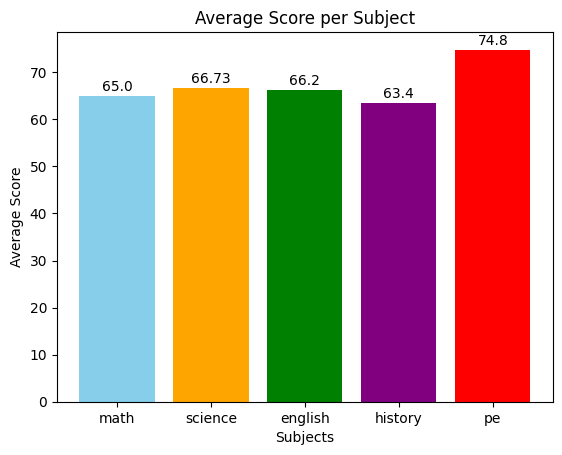

In [43]:
colors = ['skyblue', 'orange', 'green', 'purple', 'red']

plt.figure()
bars = plt.bar(subjects, avg_scores, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval,2),
             ha='center', va='bottom')

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

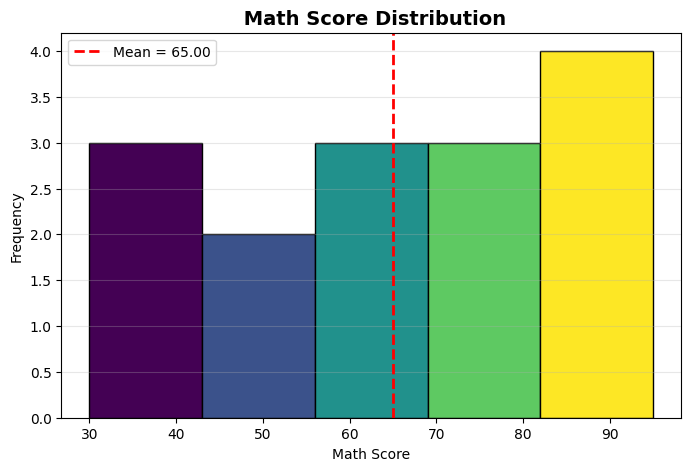

In [44]:
import numpy as np

plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(df['math'], bins=5, edgecolor='black')

colors = plt.cm.viridis(np.linspace(0,1,len(patches)))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

mean_val = df['math'].mean()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2,
            label=f"Mean = {mean_val:.2f}")

plt.title(" Math Score Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.savefig("plot2_hist.png", dpi=300)
plt.show()

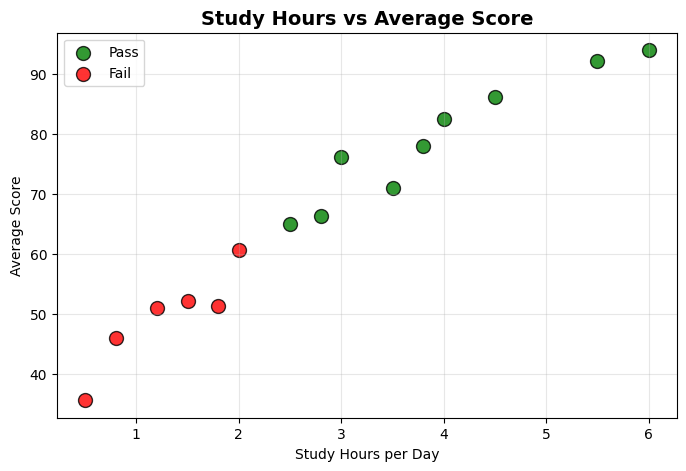

In [45]:
df['avg_score'] = df[subjects].mean(axis=1)

pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.figure(figsize=(8,5))

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
            color='green', s=100, alpha=0.8, edgecolor='black', label="Pass")

plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
            color='red', s=100, alpha=0.8, edgecolor='black', label="Fail")

plt.title("Study Hours vs Average Score", fontsize=14, fontweight='bold')
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("plot3_scatter.png", dpi=300)
plt.show()

/tmp/ipykernel_18627/1006902346.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([pass_att, fail_att],


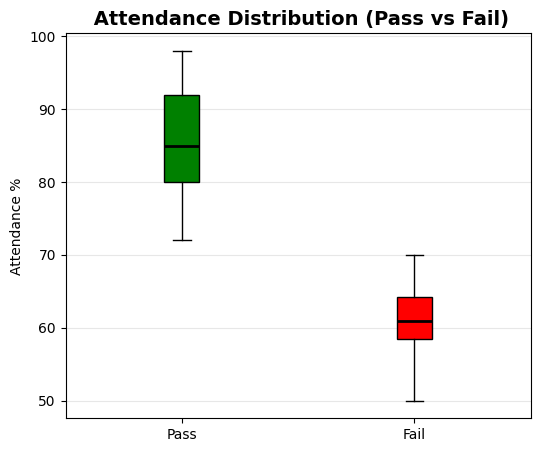

In [46]:
pass_att = df[df['passed']==1]['attendance_pct']
fail_att = df[df['passed']==0]['attendance_pct']

plt.figure(figsize=(6,5))

box = plt.boxplot([pass_att, fail_att],
                  labels=['Pass','Fail'],
                  patch_artist=True)


colors = ['green', 'red']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

for median in box['medians']:
    median.set(color='black', linewidth=2)

plt.title(" Attendance Distribution (Pass vs Fail)", fontsize=14, fontweight='bold')
plt.ylabel("Attendance %")
plt.grid(axis='y', alpha=0.3)

plt.savefig("plot4_box.png", dpi=300)
plt.show()

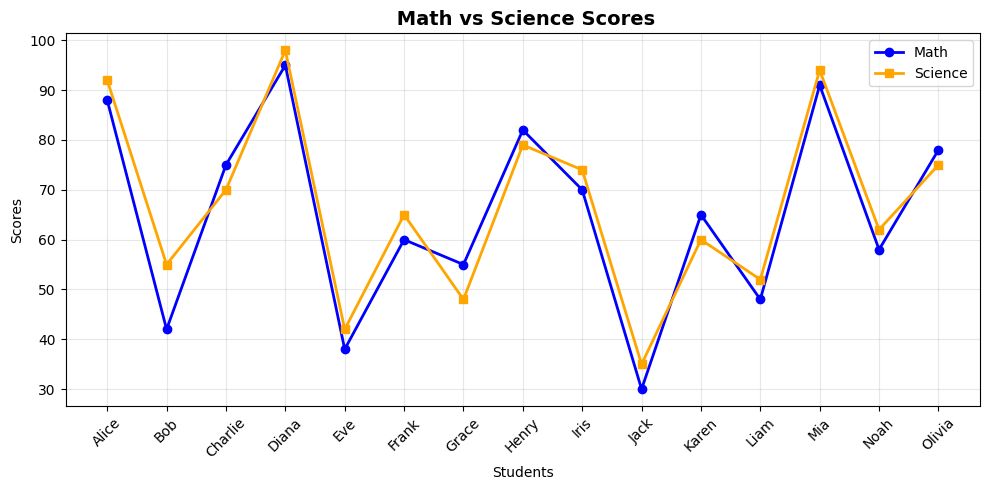

In [47]:
plt.figure(figsize=(10,5))

plt.plot(df['name'], df['math'],
         marker='o', linewidth=2, markersize=6,
         color='blue', label="Math")

plt.plot(df['name'], df['science'],
         marker='s', linewidth=2, markersize=6,
         color='orange', label="Science")

plt.xticks(rotation=45)
plt.title(" Math vs Science Scores", fontsize=14, fontweight='bold')
plt.xlabel("Students")
plt.ylabel("Scores")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot5_line.png", dpi=300)
plt.show()

## Task 3 — Data Visualization with Seaborn

In [48]:
import seaborn as sns

/tmp/ipykernel_18627/352966406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math',
/tmp/ipykernel_18627/352966406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science',


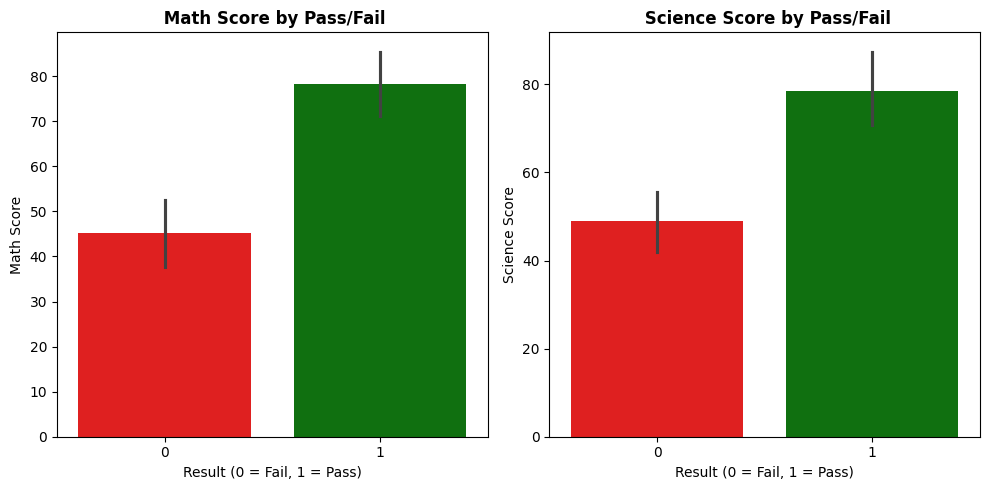

In [49]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))

sns.barplot(data=df, x='passed', y='math',
            ax=ax1, palette=['red','green'])
ax1.set_title(" Math Score by Pass/Fail", fontweight='bold')
ax1.set_xlabel("Result (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

sns.barplot(data=df, x='passed', y='science',
            ax=ax2, palette=['red','green'])
ax2.set_title(" Science Score by Pass/Fail", fontweight='bold')
ax2.set_xlabel("Result (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png", dpi=300)
plt.show()

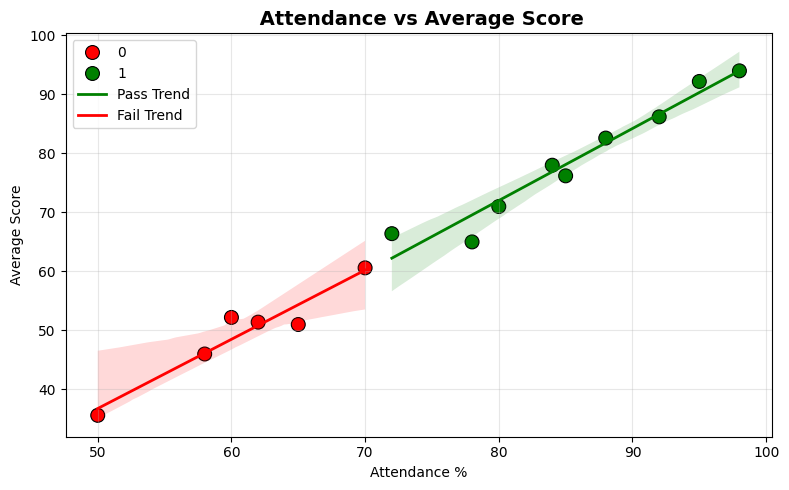

In [50]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x='attendance_pct',
                y='avg_score',
                hue='passed',
                palette={0: 'red', 1: 'green'},
                s=100,
                edgecolor='black')

sns.regplot(data=df[df['passed']==1],
            x='attendance_pct',
            y='avg_score',
            scatter=False,
            color='green',
            line_kws={'linewidth':2},
            label='Pass Trend')

sns.regplot(data=df[df['passed']==0],
            x='attendance_pct',
            y='avg_score',
            scatter=False,
            color='red',
            line_kws={'linewidth':2},
            label='Fail Trend')

plt.title(" Attendance vs Average Score", fontsize=14, fontweight='bold')
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png", dpi=300)
plt.show()

# Seaborn vs Matplotlib:
# Seaborn is easier for statistical plots and gives better visuals with less code.
# Matplotlib provides more control but requires more manual effort.
# Seaborn is preferred for quick analysis, while Matplotlib is better for customization.

##Task 4 — Machine Learning with scikit-learn

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [52]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


In [54]:
y_pred = model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "YES" if actual == pred else "NO"
    print(f"{name}: Actual={actual}, Predicted={pred} {result}")

Test Accuracy: 1.0
Jack: Actual=0, Predicted=0 YES
Liam: Actual=0, Predicted=0 YES
Alice: Actual=1, Predicted=1 YES



Feature Importance:
english: 0.813
attendance_pct: 0.522
study_hours_per_day: 0.484
pe: 0.475
math: 0.438
science: 0.323
history: 0.263


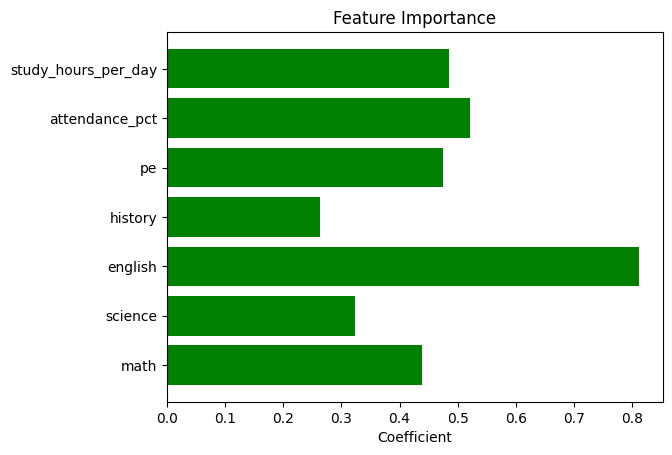

In [55]:
import numpy as np

features = X.columns
coeffs = model.coef_[0]

pairs = sorted(zip(features, coeffs), key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:")
for f, c in pairs:
    print(f"{f}: {c:.3f}")

colors = ['green' if c > 0 else 'red' for c in coeffs]

plt.figure()
plt.barh(features, coeffs, color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient")

plt.show()

##Predict for a New Student

In [56]:
new_student = [[75,70,68,65,80,82,3.2]]

new_scaled = scaler.transform(new_student)

pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("Prediction:", "Pass" if pred[0]==1 else "Fail")
print("Probability:", prob)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Downloading Result

In [57]:
from google.colab import files

files.download("students.csv")

for file in [
    "plot1_bar.png",
    "plot2_hist.png",
    "plot3_scatter.png",
    "plot4_box.png",
    "plot5_line.png",
    "plot6_seaborn_bar.png",
    "plot7_seaborn_scatter.png"
]:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>